In [68]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision.transforms as v2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import numpy as np
import cv2
import json
import itertools
import copy
import math

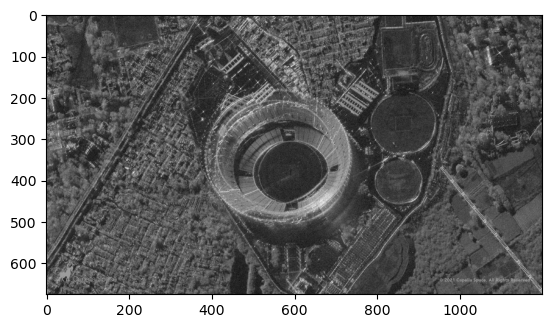

In [69]:
image = cv2.imread('lab2/sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

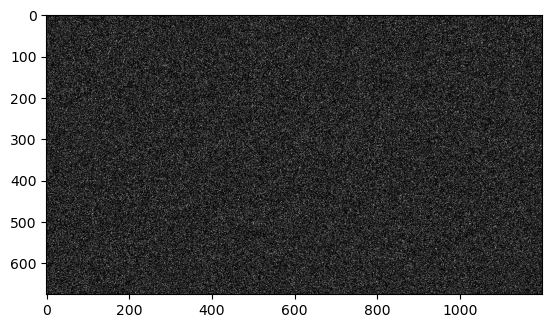

In [70]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
plt.imshow(noise_gauss, cmap="gray")

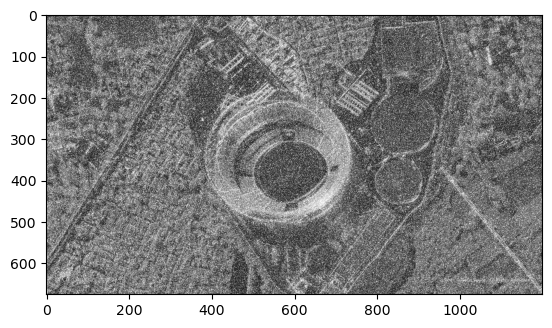

In [71]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

In [72]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
ssim_gauss = structural_similarity(image_gray, image_noise_gauss, full=False)
print(mse_gauss, ssim_gauss)

4221.864940740741 0.18745816757315886


In [ ]:
def alpha_shift(img, window_size, alpha):
    def proc(img, filter, window_size, alpha):
        img_res = img.copy()
        img_pre = img.copy()
        sz = img.shape[1] * img.shape[0]
        half_alpha = alpha // 2
        for i in range(0,img_pre.shape[0] - window_size + 1):
            for j in range(0,img_pre.shape[1] - window_size + 1):
                img_res[i:i+window_size, j:j+window_size] = filter(img_pre[i:i+window_size, j:j+window_size], window_size, alpha)
        return img_res
    def alpha_shift_step(a, window_size, alpha):
        a_pre = a.copy().astype(float).flatten()
        a_pre = np.sort(a_pre)
        for i in range(alpha // 2):
            a_pre[i] = 0
            a_pre[-i] = 0
        sum_calc = np.sum(a_pre)
        sum_calc /= (window_size * window_size - alpha)
        sum_calc = np.clip(sum_calc, 0, 255).astype(np.uint8)
        return sum_calc
    return proc(img, alpha_shift_step, window_size, alpha)

2949.366375308642 0.26177647313914326


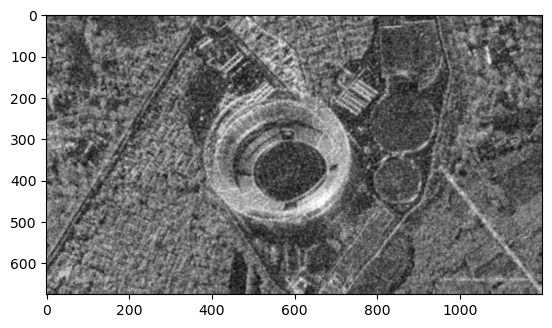

In [90]:
img_filtered = alpha_shift(image_noise_gauss, 5, 5)
mse_gauss = mean_squared_error(image_gray, img_filtered)
ssim_gauss = structural_similarity(image_gray, img_filtered, full=False)
print(mse_gauss, ssim_gauss)
plt.imshow(img_filtered, cmap="gray")